In [140]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [141]:
from data import data_loader
from features import tstat, volatility
from regime import state_labels

df = data_loader.get_data()
df = tstat.compute_tstat(df)
df = volatility.compute_volatility(df)
df = state_labels.label_volatility(df)
df = state_labels.label_regime(df)

[*********************100%***********************]  1 of 1 completed


In [142]:
df.head()

Ticker,SPY,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2015-01-05,167.508804,-0.018225,NaN,NaN,0,0
2015-01-06,165.931076,-0.009463,NaN,NaN,0,0
2015-01-07,167.998703,0.012384,NaN,NaN,0,0
2015-01-08,170.979904,0.017590,NaN,NaN,0,0
2015-01-09,169.609726,-0.008046,NaN,NaN,0,0


In [143]:
df.tail()

Ticker,SPY,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2024-12-24,594.320740,0.011054,1.432934,0.007806,0,1
2024-12-26,594.360352,0.000067,1.531649,0.007909,0,1
2024-12-27,588.103760,-0.010582,1.443918,0.007804,0,1
2024-12-30,581.392578,-0.011477,1.358181,0.007945,0,1
2024-12-31,579.277405,-0.003645,1.268188,0.008096,0,1


In [144]:
df[['Log Return', 'T-Stat_200', 'Volatility', 'Vol State', 'Regime']].tail(10)

Ticker,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,
2024-12-17,-0.004128,1.616926,0.006485,0,1
2024-12-18,-0.030257,1.587699,0.006517,0,1
2024-12-19,-0.000307,1.356806,0.007658,0,1
2024-12-20,0.011940,1.310546,0.007650,0,1
2024-12-23,0.005970,1.326529,0.007781,0,1
2024-12-24,0.011054,1.432934,0.007806,0,1
2024-12-26,0.000067,1.531649,0.007909,0,1
2024-12-27,-0.010582,1.443918,0.007804,0,1
2024-12-30,-0.011477,1.358181,0.007945,0,1


In [145]:
df[['Vol State', 'Regime']].dropna().dtypes

Ticker
Vol State    int64
Regime       int64
dtype: object

In [146]:
df['Log Return'].std()

0.01113693895689429

In [147]:
df['T-Stat_200'].describe()

count    2315.000000
mean        0.922884
std         0.926917
min        -1.310080
25%         0.207417
50%         0.924993
75%         1.697503
max         3.439003
Name: T-Stat_200, dtype: float64

In [148]:
df['Volatility'].describe()

count    2455.000000
mean        0.009738
std         0.005574
min         0.003136
25%         0.006557
50%         0.008349
75%         0.011527
max         0.038924
Name: Volatility, dtype: float64

In [149]:
df.isna().sum()

Ticker
SPY             0
Log Return      0
T-Stat_200    200
Volatility     60
Vol State       0
Regime          0
dtype: int64

In [150]:
df['Regime'].value_counts(normalize = True)

Regime
 0    0.557455
 1    0.434592
-1    0.007952
Name: proportion, dtype: float64

In [151]:
df['Vol State'].value_counts(normalize = True)

Vol State
0    0.769384
1    0.230616
Name: proportion, dtype: float64

<Axes: xlabel='Date', ylabel='T-Stat_200'>

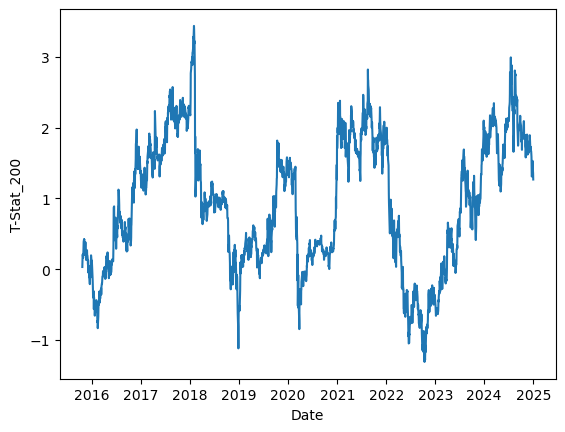

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data = df['T-Stat_200'])

<Axes: xlabel='Date', ylabel='Volatility'>

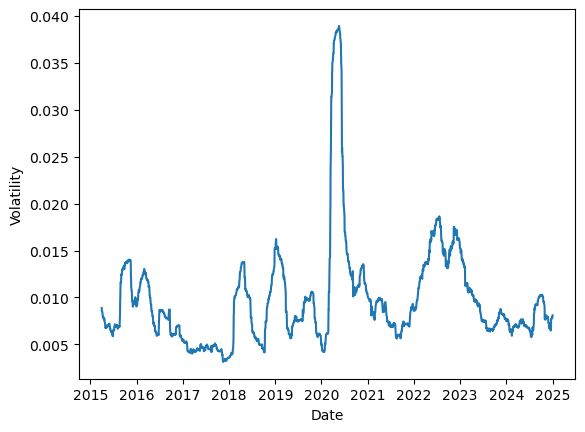

In [153]:
sns.lineplot(data = df['Volatility'])

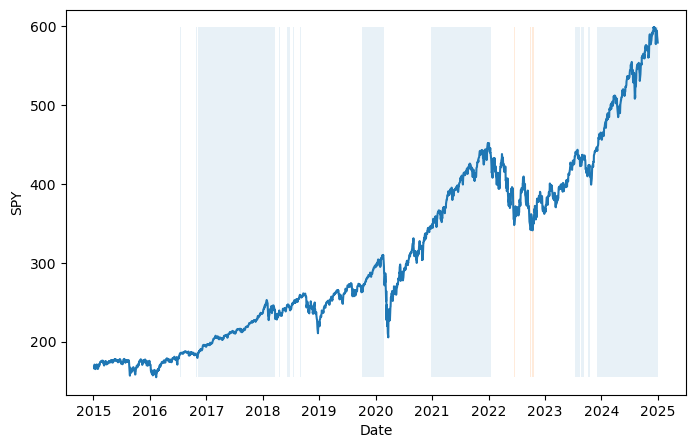

In [154]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.lineplot(data = df['SPY'], ax = ax)
ax.fill_between(df.index, df['SPY'].min(), df['SPY'].max(), where = (df['Regime'] == 1), alpha = 0.1, label = 'Bull')
ax.fill_between(df.index, df['SPY'].min(), df['SPY'].max(), where = (df['Regime'] == -1), alpha = 0.15, label = 'Bear')

In [155]:
df['Forward Return'] = df['Log Return'].shift(-1)
df_new = df.dropna(subset = ['Forward Return'])

bull_mean = df_new.loc[df['Regime'] == 1, 'Forward Return'].mean()
neutral_mean = df_new.loc[df['Regime'] == 0, 'Forward Return'].mean()
bear_mean = df_new.loc[df['Regime'] == -1, 'Forward Return'].mean()

print(bull_mean)
print(neutral_mean)
print(bear_mean)

df_new.loc[df_new['Regime'] == -1, 'Forward Return'].describe()

0.000610197539249796
0.0003268202367916891
0.005810393758104244


count    20.000000
mean      0.005810
std       0.017141
min      -0.023052
25%      -0.006543
50%       0.002917
75%       0.024224
max       0.030516
Name: Forward Return, dtype: float64

In [156]:
df_new.groupby('Regime')['Forward Return'].std()

Regime
-1    0.017141
 0    0.013265
 1    0.007337
Name: Forward Return, dtype: float64

In [157]:
import numpy as np

bear_forward = df_new.loc[df_new['Regime'] == -1, 'Forward Return']

t = bear_forward.mean() / (bear_forward.std() / np.sqrt(len(bear_forward)))
print(t)

1.5159412999051614


In [158]:
bull_forward = df_new.loc[df_new['Regime'] == 1, 'Forward Return']

t = bull_forward.mean() / (bull_forward.std() / np.sqrt(len(bull_forward)))
print(t)

2.748411751860237


In [159]:
neutral_forward = df_new.loc[df_new['Regime'] == 0, 'Forward Return']

t = neutral_forward.mean() / (neutral_forward.std() / np.sqrt(len(neutral_forward)))
print(t)

0.92248705367713


In [160]:
df['Forward Vol'] = df['Volatility'].shift(-1)
df_new = df.dropna(subset =['Forward Vol'])

df_new.groupby('Vol State')['Forward Vol'].mean()

Vol State
0    0.007760
1    0.016131
Name: Forward Vol, dtype: float64

In [161]:
from regime import matrix

df = matrix.initialize_state(df)

transition_matrix = matrix.build_stationary_matrix(df)
print(transition_matrix)

Next State      -1_1       0_0       0_1       1_0       1_1
State                                                       
-1_1        0.800000  0.000000  0.200000  0.000000  0.000000
0_0         0.000000  0.968951  0.006424  0.024625  0.000000
0_1         0.008547  0.014957  0.970085  0.000000  0.006410
1_0         0.000000  0.021000  0.000000  0.975000  0.004000
1_1         0.000000  0.000000  0.043478  0.032609  0.923913


In [162]:
from regime import entropy

entropy_vector = entropy.find_entropy_vector(transition_matrix)
print(entropy_vector)

State
-1_1    0.500402
0_0     0.154200
0_1     0.165395
1_0     0.127899
1_1     0.321067
dtype: float64


<Axes: xlabel='Date', ylabel='Stationary Entropy'>

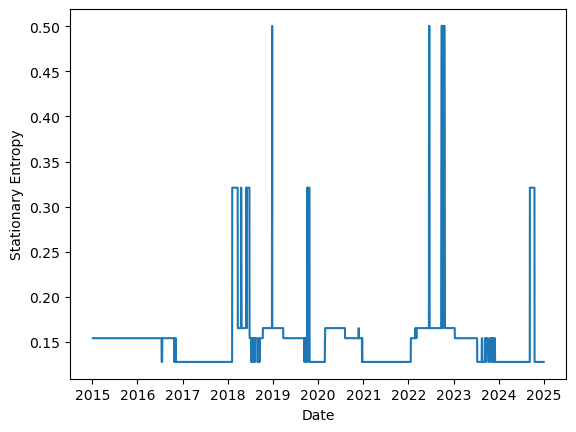

In [163]:
df = entropy.build_stationary_entropy(df, entropy_vector)

sns.lineplot(data = df['Stationary Entropy'])

<Axes: xlabel='Date', ylabel='Expanding Entropy'>

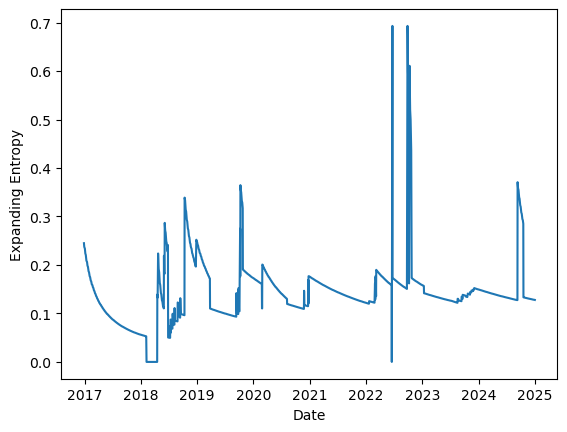

In [171]:
df = entropy.build_expanding_entropy(df)

sns.lineplot(data = df['Expanding Entropy'])

In [165]:
df[[f'T-Stat_200', 'Log Return']].corr()

Ticker,T-Stat_200,Log Return
Ticker,,
T-Stat_200,1.000000,-0.016617
Log Return,-0.016617,1.000000


In [166]:
df[['Volatility', 'Log Return']].corr()

Ticker,Volatility,Log Return
Ticker,,
Volatility,1.000000,0.035205
Log Return,0.035205,1.000000


In [167]:
df[[f'T-Stat_200', 'Forward Return']].corr()

Ticker,T-Stat_200,Forward Return
Ticker,,
T-Stat_200,1.000000,-0.009882
Forward Return,-0.009882,1.000000


In [168]:
df[['Volatility', 'Forward Return']].corr()

Ticker,Volatility,Forward Return
Ticker,,
Volatility,1.000000,0.033796
Forward Return,0.033796,1.000000
